# <span style="color:red">HW2_Reza_Zamani</span>

# <span style="color:green">This project is for Python for MFE program at UC Berkeley </span>

In [16]:
# ----------------------------
# Parameters (Papermill-compatible)
# ----------------------------
ticker = "AAPL"          # Stock ticker to analyze
start_date = "2024-01-01"  # Analysis start date (YYYY-MM-DD)
end_date = "2024-12-31"    # Analysis end date (YYYY-MM-DD)

# ----------------------------
# Imports + plotting setup
# ----------------------------
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6)})

# ----------------------------
# Data loading (cleaned table)
# ----------------------------
DB_PATH = "data3_cleaned.db"
TABLE = "ohlc_hw_cleaned"

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql(
        f"""
        SELECT ts, open, high, low, close, adj_close, volume, ticker
        FROM {TABLE}
        WHERE ticker = ?
          AND ts BETWEEN ? AND ?
        ORDER BY ts
        """,
        conn,
        params=(ticker, start_date, end_date),
    )

df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
df = df.dropna(subset=["ts"]).sort_values("ts").reset_index(drop=True)

print(f"{ticker} from {start_date} to {end_date}: {len(df):,} trading days")
display(df.head(3))
display(df.tail(3))


AAPL from 2024-01-01 to 2024-12-31: 223 trading days


,ts,open,high,low,close,adj_close,volume,ticker
0,2024-01-02,187.15,188.44,183.89,185.64,184.94,82488674,AAPL
1,2024-01-03,184.22,185.88,183.43,184.25,183.55,58414460,AAPL
2,2024-01-04,182.15,183.09,180.88,181.91,181.22,71983570,AAPL


,ts,open,high,low,close,adj_close,volume,ticker
220,2024-10-16,231.60,232.12,229.84,231.78,231.78,34082240,AAPL
221,2024-10-17,233.43,233.85,230.52,232.15,232.15,32993810,AAPL
222,2024-10-18,236.18,236.18,234.01,235.00,235.00,45441281,AAPL


In [17]:
# ----------------------------
# Financial metrics utilities
# Here we define financial indices 
# ----------------------------
import numpy as np
import pandas as pd


def calculate_returns(prices: pd.Series) -> pd.Series:
    """
    Calculate daily log returns.
    """
    prices = prices.astype(float)
    return np.log(prices / prices.shift(1))


def calculate_volatility(returns: pd.Series, window: int = 20) -> pd.Series:
    """
    Calculate annualized rolling volatility.
    """
    return returns.rolling(window).std() * np.sqrt(252)


def calculate_max_drawdown(prices: pd.Series) -> pd.Series:
    """
    Calculate running maximum drawdown from peak.
    """
    prices = prices.astype(float)
    cum_max = prices.cummax()
    drawdown = (prices - cum_max) / cum_max
    return drawdown


def calculate_sharpe_ratio(
    returns: pd.Series,
    risk_free_rate: float = 0.02,
    trading_days: int = 252,
) -> float:
    """
    Calculate annualized Sharpe ratio.
    """
    excess_return = returns.mean() * trading_days - risk_free_rate
    annual_vol = returns.std() * np.sqrt(trading_days)

    if annual_vol == 0 or np.isnan(annual_vol):
        return np.nan

    return excess_return / annual_vol


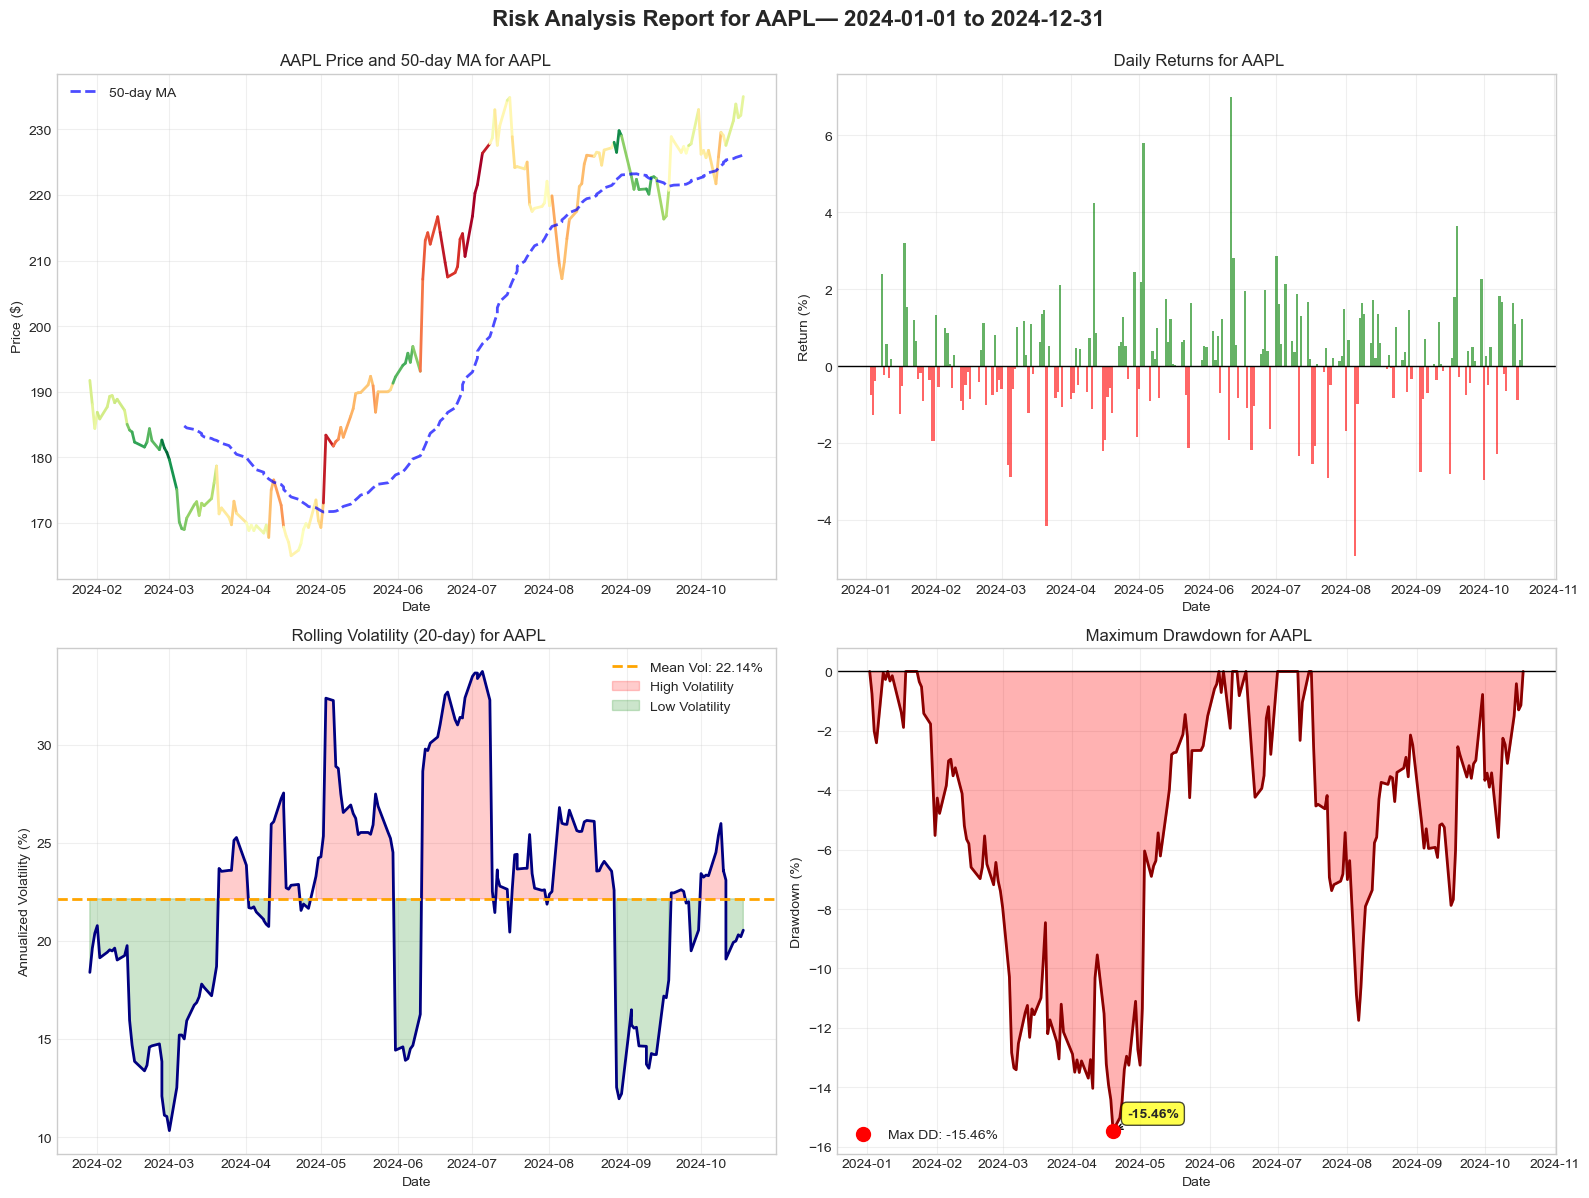

In [18]:
# ----------------------------
# Ensure df_stock exists (corrects NameError)
# ----------------------------
df_stock = df.copy()
df_stock["ts"] = pd.to_datetime(df_stock["ts"], errors="coerce")
df_stock = df_stock.dropna(subset=["ts"]).sort_values("ts").set_index("ts")

# ----------------------------
# Compute metrics
# ----------------------------
prices = df_stock["close"]

returns = calculate_returns(prices)
volatility = calculate_volatility(returns, window=20)
drawdown = calculate_max_drawdown(prices)
ma_50 = prices.rolling(50).mean()

# ----------------------------
# Figure layout
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f" Risk Analysis Report for {ticker}— {start_date} to {end_date}",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

ax_price, ax_ret, ax_vol, ax_dd = axes.flatten()

# ----------------------------
# 1) Price + 50-day MA (volatility-colored)
# ----------------------------
vol_norm = (volatility - volatility.min()) / (volatility.max() - volatility.min())
cmap = plt.cm.RdYlGn_r

for i in range(1, len(prices)):
    if pd.notna(vol_norm.iloc[i]):
        ax_price.plot(
            prices.index[i - 1 : i + 1],
            prices.iloc[i - 1 : i + 1],
            color=cmap(vol_norm.iloc[i]),
            linewidth=2,
        )

ax_price.plot(
    prices.index,
    ma_50,
    label="50-day MA",
    color="blue",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
)

ax_price.set(title=f"{ticker} Price and 50-day MA for {ticker} ", xlabel="Date", ylabel="Price ($)")
ax_price.legend()
ax_price.grid(alpha=0.3)

# ----------------------------
# 2) Daily returns
# ----------------------------
ret_colors = np.where(returns > 0, "green", "red")

ax_ret.bar(
    returns.index,
    returns * 100,
    color=ret_colors,
    alpha=0.6,
    width=1,
)
ax_ret.axhline(0, color="black", linewidth=1)

ax_ret.set(title=f" Daily Returns for {ticker}", xlabel="Date", ylabel="Return (%)")
ax_ret.grid(alpha=0.3)

# ----------------------------
# 3) Rolling volatility
# ----------------------------
vol_pct = volatility * 100
mean_vol = volatility.mean() * 100

ax_vol.plot(volatility.index, vol_pct, color="navy", linewidth=2)
ax_vol.axhline(
    mean_vol,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Mean Vol: {mean_vol:.2f}%",
)

ax_vol.fill_between(
    volatility.index,
    vol_pct,
    mean_vol,
    where=vol_pct >= mean_vol,
    color="red",
    alpha=0.2,
    label="High Volatility",
)
ax_vol.fill_between(
    volatility.index,
    vol_pct,
    mean_vol,
    where=vol_pct < mean_vol,
    color="green",
    alpha=0.2,
    label="Low Volatility",
)

ax_vol.set(
    title=f" Rolling Volatility (20-day) for {ticker}",
    xlabel="Date",
    ylabel="Annualized Volatility (%)",
)
ax_vol.legend()
ax_vol.grid(alpha=0.3)

# ----------------------------
# 4) Maximum drawdown
# ----------------------------
dd_pct = drawdown * 100
max_dd_date = dd_pct.idxmin()
max_dd_value = dd_pct.min()

ax_dd.fill_between(drawdown.index, 0, dd_pct, color="red", alpha=0.3)
ax_dd.plot(drawdown.index, dd_pct, color="darkred", linewidth=2)

ax_dd.scatter(
    max_dd_date,
    max_dd_value,
    color="red",
    s=100,
    zorder=5,
    label=f"Max DD: {max_dd_value:.2f}%",
)

ax_dd.annotate(
    f"{max_dd_value:.2f}%",
    xy=(max_dd_date, max_dd_value),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="yellow", alpha=0.7),
    arrowprops=dict(arrowstyle="->"),
)

ax_dd.axhline(0, color="black", linewidth=1)
ax_dd.set(title=f" Maximum Drawdown for {ticker}", xlabel="Date", ylabel="Drawdown (%)")
ax_dd.legend()
ax_dd.grid(alpha=0.3)

# ----------------------------
# Final layout
# ----------------------------
plt.tight_layout()
plt.savefig(f"{ticker}_ risk analysis_2024.png")
plt.show()

